<a href="https://colab.research.google.com/github/joyhwp/personal_projects/blob/main/07_LLM_Engineering_Sessions/VLM_%ED%8C%8C%EC%9D%B8%ED%8A%9C%EB%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

실습의 목표는 일반적인 대화형 VLM을 튜닝하여, 쇼핑몰의 상품 이미지와 이름만 보고 성별, 계절, 색상 등 7가지 핵심 정보를 완벽한 형태의 JSON 포맷으로 자동 추출하는 '패션 특화 분류 AI'를 만드는 것

# VLM Fine-Tuning


In [ ]:
# Install Pytorch & other libraries
%pip install -q tensorboard wandb

# Install Hugging Face libraries
%pip install -q --upgrade \
  "transformers>=4.46.0" \
  "datasets>=3.0.1" \
  "accelerate>=0.34.2" \
  "evaluate>=0.4.3" \
  "bitsandbytes>=0.45.0" \
  "trl>=0.11.1" \
  "peft>=0.13.0" \
  "qwen-vl-utils"

%pip install "Pillow>=9.4.0"
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 35.7 MB/s eta 0:00:00


In [ ]:
import io
import json
from PIL import Image
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq, AutoProcessor, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer
from transformers import Qwen2VLProcessor
from qwen_vl_utils import process_vision_info
from peft import LoraConfig

In [ ]:
import wandb
wandb.init(mode="disabled")

In [ ]:
# 시스템(assistant)에게 주어진 역할
system_message = "당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다."

# 실제로 사용자 입력 -> 모델이 답해야 하는 프롬프트
prompt = """입력 정보:
- name: {name}
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}}

# 예시
{{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
"""

In [ ]:
def combine_cols_to_label(example):
    # 실제 컬럼명에 맞게 수정
    label_dict = {
        "gender": example["gender"],
        "masterCategory": example["masterCategory"],
        "subCategory": example["subCategory"],
        "season": example["season"],
        "usage": example["usage"],
        "baseColour": example["baseColour"],
        "articleType": example["articleType"],
    }
    example["label"] = json.dumps(label_dict, ensure_ascii=False)
    return example

def format_data(sample):
   # Image.Image를 PngImageFile로 변환
   buffer = io.BytesIO()
   sample["image"].save(buffer, format='PNG')
   buffer.seek(0)
   image = Image.open(buffer)

   return {
       "messages": [
           {
               "role": "system",
               "content": [
                   {
                       "type": "text",
                       "text": system_message
                   }
               ],
           },
           {
               "role": "user",
               "content": [
                   {
                       "type": "text",
                       "text": prompt.format(name=sample["productDisplayName"]),
                   },
                   {
                       "type": "image",
                       "image": image,
                   }
               ],
           },
           {
               "role": "assistant",
               "content": [
                   {
                       "type": "text",
                       "text": sample["label"],
                   }
               ],
           },
       ],
   }

In [ ]:
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
dataset_add_label = dataset.map(combine_cols_to_label)
dataset_add_label = dataset_add_label.shuffle(seed=4242)

In [ ]:
dataset_add_label[0]

{'id': 15516,
 'gender': 'Men',
 'masterCategory': 'Footwear',
 'subCategory': 'Flip Flops',
 'articleType': 'Flip Flops',
 'baseColour': 'Navy Blue',
 'season': 'Fall',
 'year': 2011.0,
 'usage': 'Casual',
 'productDisplayName': 'Rockport Men Altrezlp Navy Blue Flip Flops',
 'image': <PIL.Image.Image image mode=RGB size=60x80>,
 'label': '{"gender": "Men", "masterCategory": "Footwear", "subCategory": "Flip Flops", "season": "Fall", "usage": "Casual", "baseColour": "Navy Blue", "articleType": "Flip Flops"}'}

In [ ]:
formatted_dataset = [format_data(row) for row in dataset_add_label]

In [ ]:
formatted_dataset[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': '당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다.'}]},
  {'role': 'user',
   'content': [{'type': 'text',
     'text': '입력 정보:\n- name: Rockport Men Altrezlp Navy Blue Flip Flops\n- image: [image]\n\n위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:\n1) gender\n2) masterCategory\n3) subCategory\n4) season\n5) usage\n6) baseColour\n7) articleType\n\n출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:\n{\n  "gender": "예시값",\n  "masterCategory": "예시값",\n  "subCategory": "예시값",\n  "season": "예시값",\n  "usage": "예시값",\n  "baseColour": "예시값",\n  "articleType": "예시값"\n}\n\n# 예시\n{\n  "gender": "Men",\n  "masterCategory": "Accessories",\n  "subCategory": "Eyewear",\n  "season": "Winter",\n  "usage": "Casual",\n  "baseColour": "Blue",\n  "articleType": "Sunglasses"\n}\n\n# 주의\n- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.\n'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=60x80>}]},
  {'role': 'assista

In [ ]:
# 소량 데이터로 빠르게 학습
train_dataset = formatted_dataset[:50]      # 50개만 학습
test_dataset = formatted_dataset[50:60]    # 10개 테스트

In [ ]:
print('학습 데이터의 개수:', len(train_dataset))
print('테스트 데이터의 개수:', len(test_dataset))

학습 데이터의 개수: 50
테스트 데이터의 개수: 10


In [ ]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"

# 4-bit 양자화 설정 (NF4)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # 4비트로 로드
    bnb_4bit_use_double_quant=True,         # 이중 양자화로 추가 메모리 절약
    bnb_4bit_quant_type="nf4",              # NormalFloat4 양자화 타입
    bnb_4bit_compute_dtype=torch.float16,   # 연산 시 fp16 사용 (T4 최적)
)

# 모델 로드 (4-bit 양자화 적용)
model = AutoModelForVision2Seq.from_pretrained(
   model_id,
   device_map="auto",
   torch_dtype=torch.float16,              # T4는 fp16이 효율적 (bf16 대신)
   quantization_config=bnb_config,          # 4-bit 양자화 적용
)
processor = AutoProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Preparation for inference
text = processor.apply_chat_template(
    train_dataset[0]["messages"], tokenize=False, add_generation_prompt=False
)
print(text)

<|im_start|>system
당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다.<|im_end|>
<|im_start|>user
입력 정보:
- name: Rockport Men Altrezlp Navy Blue Flip Flops
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}

# 예시
{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
<|vision_start|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant
{"gender": "Men", "masterCategory": "Footwear", "subCategory": "Flip Flops", "season": "Fall", "usage": "Casual", "baseColour": "Navy Blue", "articleType": "Flip Flops"}<|im_end|>



In [ ]:
# LoRA 설정
peft_config = LoraConfig(
       lora_alpha=32,                        # 128 → 32 (rank에 비례하여 축소)
       lora_dropout=0.05,
       r=64,                                 # 256 → 64 (VRAM 절감)
       bias="none",
       target_modules=[
           "q_proj",
           "up_proj",
           "o_proj",
           "k_proj",
           "down_proj",
           "gate_proj",
           "v_proj"
       ],
       task_type="CAUSAL_LM",
)

In [ ]:
args = SFTConfig(
    output_dir="output_dir",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=16,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # ← 추가 (CheckpointError 해결)
    optim="adamw_8bit",
    logging_steps=5,                   # 10 → 5
    save_strategy="epoch",             # steps → epoch (저장 횟수 줄여 속도 개선)
    bf16=True,
    learning_rate=1e-4,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="constant",
    push_to_hub=False,
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
    report_to="none"                   # 문자열 "none"
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
def collate_fn(examples):
   """
   텍스트와 이미지가 포함된 대화 데이터를 모델 학습에 적합한 형태로 변환하는 함수

   Args:
       examples: 각각 "messages" 키를 가진 딕셔너리들의 리스트
                messages는 role(system/user/assistant)과 content를 포함하는 대화 형태

   Returns:
       batch: 모델 학습에 사용할 수 있는 토큰화된 텍스트, 이미지, 라벨이 포함된 배치
   """

   # 1단계: 텍스트 전처리 - 채팅 템플릿 적용
   texts = [processor.apply_chat_template(example["messages"], tokenize=False) for example in examples]

   # 2단계: 이미지 데이터 추출 및 전처리
   image_inputs = [process_vision_info(example["messages"])[0] for example in examples]

   # 3단계: 텍스트 토크나이징 + 이미지 인코딩
   batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)

   # 4단계: 라벨 생성 (손실 계산용)
   labels = batch["input_ids"].clone()

   # 5단계: 패딩 토큰 손실 계산에서 제외
   labels[labels == processor.tokenizer.pad_token_id] = -100

   # 6단계: 이미지 토큰 손실 계산에서 제외
   if isinstance(processor, Qwen2VLProcessor):
       image_tokens = [151652, 151653, 151655]
   else:
       image_tokens = [processor.tokenizer.convert_tokens_to_ids(processor.image_token)]

   for image_token_id in image_tokens:
       labels[labels == image_token_id] = -100

   # 7단계: 최종 배치에 라벨 추가
   batch["labels"] = labels

   return batch

In [ ]:
# 단일 예시 확인
example = train_dataset[0]
print("단일 예시 데이터:")
print(example)

# collate_fn 테스트 (배치 크기 1로)
batch = collate_fn([example])
print("\n처리된 배치 데이터:")
print("입력 ID 형태:", batch["input_ids"].shape)
print("어텐션 마스크 형태:", batch["attention_mask"].shape)
print("이미지 픽셀 형태:", batch["pixel_values"].shape)
print("레이블 형태:", batch["labels"].shape)

단일 예시 데이터:
{'messages': [{'role': 'system', 'content': [{'type': 'text', 'text': '당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다.'}]}, {'role': 'user', 'content': [{'type': 'text', 'text': '입력 정보:\n- name: Rockport Men Altrezlp Navy Blue Flip Flops\n- image: [image]\n\n위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:\n1) gender\n2) masterCategory\n3) subCategory\n4) season\n5) usage\n6) baseColour\n7) articleType\n\n출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:\n{\n  "gender": "예시값",\n  "masterCategory": "예시값",\n  "subCategory": "예시값",\n  "season": "예시값",\n  "usage": "예시값",\n  "baseColour": "예시값",\n  "articleType": "예시값"\n}\n\n# 예시\n{\n  "gender": "Men",\n  "masterCategory": "Accessories",\n  "subCategory": "Eyewear",\n  "season": "Winter",\n  "usage": "Casual",\n  "baseColour": "Blue",\n  "articleType": "Sunglasses"\n}\n\n# 주의\n- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.\n'}, {'type': 'image', 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=60x80 at 0x7C23685AD9D0>}]}, {'role': 'assista

In [ ]:
print('입력에 대한 정수 인코딩 결과:')
print(batch["input_ids"][0])

입력에 대한 정수 인코딩 결과:
tensor([151644,   8948,    198,  64795,  82528,  33704,  90667,  21329,  80573,
        138017,  79632,   3153,      8,  42039, 126558,  45104,    101,  92031,
            14, 141274,  32077,  60039,  18411,  57835, 126605,  42905, 128618,
         97929,  54070, 142713,  78952,     13, 151645,    198, 151644,    872,
           198,  43866,  28754,  60039,    510,     12,    829,     25,   9127,
           403,  11012,   1674,  10157,     89,  13545,  19036,   8697,  40284,
         19580,   1690,    198,     12,   2168,     25,    508,   1805,   2533,
         80901,  60039,  18411,  81718, 144059,  42039,     11, 136646,    220,
            22,  19969,  21329,   1376,  19391, 128605,  93668,   4718, 141966,
         17380,  57835, 126605,  33883,  55673,  50302,    510,     16,      8,
          9825,    198,     17,      8,   7341,   6746,    198,     18,      8,
          1186,   6746,    198,     19,      8,   3200,    198,     20,      8,
         10431,    198

In [ ]:
print('레이블에 대한 정수 인코딩 결과:')
print(batch["labels"][0])

레이블에 대한 정수 인코딩 결과:
tensor([151644,   8948,    198,  64795,  82528,  33704,  90667,  21329,  80573,
        138017,  79632,   3153,      8,  42039, 126558,  45104,    101,  92031,
            14, 141274,  32077,  60039,  18411,  57835, 126605,  42905, 128618,
         97929,  54070, 142713,  78952,     13, 151645,    198, 151644,    872,
           198,  43866,  28754,  60039,    510,     12,    829,     25,   9127,
           403,  11012,   1674,  10157,     89,  13545,  19036,   8697,  40284,
         19580,   1690,    198,     12,   2168,     25,    508,   1805,   2533,
         80901,  60039,  18411,  81718, 144059,  42039,     11, 136646,    220,
            22,  19969,  21329,   1376,  19391, 128605,  93668,   4718, 141966,
         17380,  57835, 126605,  33883,  55673,  50302,    510,     16,      8,
          9825,    198,     17,      8,   7341,   6746,    198,     18,      8,
          1186,   6746,    198,     19,      8,   3200,    198,     20,      8,
         10431,    19

In [ ]:
# 토큰 디코딩 예시 (입력 텍스트가 어떻게 변환되었는지 확인)
decoded_text = processor.tokenizer.decode(batch["input_ids"][0])
print("\n디코딩된 텍스트:")
print(decoded_text)


디코딩된 텍스트:
<|im_start|>system
당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다.<|im_end|>
<|im_start|>user
입력 정보:
- name: Rockport Men Altrezlp Navy Blue Flip Flops
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}

# 예시
{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant
{"gender": "Men", "masterCategory": "Footwear", "subCategory": "Flip Flops", "season": "Fall", "usage": "Casual

In [ ]:
# tokenizer= → processing_class=
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    peft_config=peft_config,
    processing_class=processor.tokenizer
)


In [ ]:
# 학습 시작
trainer.train()   # 모델이 자동으로 허브와 output_dir에 저장됨

# 모델 저장
trainer.save_model()   # 최종 모델을 저장

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss


# LoRA 어댑터 병합 및 HuggingFace 업로드

학습된 LoRA 어댑터를 베이스 모델에 병합하고 HuggingFace Hub에 업로드합니다.

In [ ]:
# HuggingFace 토큰 설정 (Colab Secrets에서 HF_TOKEN 등록 필요)
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

In [ ]:
import os

# 저장된 체크포인트 확인
output_dir = "./output_dir"
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]
    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    print("사용 가능한 체크포인트:", checkpoints)
    print(f"\n마지막 체크포인트: {checkpoints[-1]}")
else:
    print("output_dir이 없습니다. 먼저 fine-tuning 노트북을 실행하세요.")

사용 가능한 체크포인트: ['checkpoint-2', 'checkpoint-4']

마지막 체크포인트: checkpoint-4


In [ ]:
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText

# === 아래 경로를 위에서 확인한 체크포인트에 맞게 수정하세요 ===
adapter_path = "./output_dir/checkpoint-4"    # 실제 체크포인트 번호로 변경
base_model_id = "Qwen/Qwen2-VL-2B-Instruct"   # 학습 시 사용한 모델과 동일
merged_path = "merged"

# 베이스 모델 로드 (2B는 Colab에서 메모리 충분)
model = AutoModelForImageTextToText.from_pretrained(base_model_id, low_cpu_mem_usage=True)

# LoRA 어댑터 로드 및 병합
print(f"Loading and merging PEFT from: {adapter_path}")
peft_model = PeftModel.from_pretrained(model, adapter_path)
merged_model = peft_model.merge_and_unload()
merged_model.save_pretrained(merged_path, safe_serialization=True, max_shard_size="2GB")

# 프로세서(토크나이저) 저장
processor = AutoProcessor.from_pretrained(base_model_id)
processor.save_pretrained(merged_path)

print("병합 완료!")

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading and merging PEFT from: ./output_dir/checkpoint-4


Writing model shards:   0%|          | 0/3 [00:00<?, ?it/s]

병합 완료!


In [ ]:
from huggingface_hub import HfApi
api = HfApi()

username = "joycep"
MODEL_NAME = "Qwen2-VL-2B-Instruct-fashion-product-images-small"

In [ ]:
api.create_repo(
    token=HF_TOKEN,
    repo_id=f"{username}/{MODEL_NAME}",
    repo_type="model"
)

api.upload_folder(
    token=HF_TOKEN,
    repo_id=f"{username}/{MODEL_NAME}",
    folder_path="merged",
)

print(f"업로드 완료! https://huggingface.co/{username}/{MODEL_NAME}")

# VLM 추론 및 평가

학습/병합된 모델로 추론하고 F1 Score로 평가합니다.

## 1. 모델 로드

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# === 모델 경로 설정 ===
# 방법 1: 이전 노트북에서 merged 폴더를 저장한 경우
# MODEL_PATH = "./merged"

# 방법 2: HuggingFace Hub에 업로드한 경우
MODEL_PATH = "joycep/Qwen2-VL-2B-Instruct-fashion-product-images-small"

# 4-bit 양자화 설정 (T4 VRAM 절감)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=bnb_config,
)
processor = AutoProcessor.from_pretrained(MODEL_PATH)

print(f"모델 로드 완료: {MODEL_PATH}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

모델 로드 완료: jaehun12/Qwen2-VL-2B-Instruct-fashion-product-images-small


## 2. 테스트 데이터 로드 및 전처리

In [ ]:
import io
import json
from PIL import Image
from datasets import load_dataset

# 시스템 프롬프트
system_message = "당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다."

prompt = """입력 정보:
- name: {name}
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}}

# 예시
{{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
"""

In [ ]:
def combine_cols_to_label(example):
    label_dict = {
        "gender": example["gender"],
        "masterCategory": example["masterCategory"],
        "subCategory": example["subCategory"],
        "season": example["season"],
        "usage": example["usage"],
        "baseColour": example["baseColour"],
        "articleType": example["articleType"],
    }
    example["label"] = json.dumps(label_dict, ensure_ascii=False)
    return example

def format_data(sample):
    buffer = io.BytesIO()
    sample["image"].save(buffer, format='PNG')
    buffer.seek(0)
    image = Image.open(buffer)

    return {
        "messages": [
            {
                "role": "system",
                "content": [{"type": "text", "text": system_message}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt.format(name=sample["productDisplayName"])},
                    {"type": "image", "image": image},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": sample["label"]}],
            },
        ],
    }

In [ ]:
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
dataset_add_label = dataset.map(combine_cols_to_label)
dataset_add_label = dataset_add_label.shuffle(seed=4242)

formatted_dataset = [format_data(row) for row in dataset_add_label]

train_dataset = formatted_dataset[:50]
test_dataset = formatted_dataset[50:60]

print(f"테스트 데이터: {len(test_dataset)}개")

Map:   0%|          | 0/44072 [00:00<?, ? examples/s]

테스트 데이터: 10개


## 3. 추론 함수 정의

In [ ]:
def run_inference(model, processor, messages):
    """단일 샘플에 대해 추론을 실행합니다."""

    # user까지만 포함하는 메시지 (assistant 응답 제외)
    input_messages = messages[:2]  # system + user만

    # 텍스트 전처리
    text = processor.apply_chat_template(
        input_messages, tokenize=False, add_generation_prompt=True
    )

    # 이미지 추출
    image_inputs, _ = process_vision_info(input_messages)

    # 토크나이징
    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    # 생성
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.1,
            top_p=0.001,
            repetition_penalty=1.05,
            do_sample=True,
        )

    # 입력 부분 제거 후 디코딩
    generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text.strip()

## 4. 임의의 샘플 한 개 추론

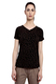


레이블: {"gender": "Women", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Fall", "usage": "Casual", "baseColour": "Black", "articleType": "Tops"}
모델 예측: {
  "gender": "Women",
  "masterCategory": "Clothing",
  "subCategory": "Top",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Black",
  "articleType": "T-shirt"
}


In [ ]:
from IPython.display import display

# 테스트 샘플 선택
test_sample = test_dataset[0]["messages"]

# 이미지 표시
image_inputs, _ = process_vision_info(test_sample)
display(image_inputs[0])

# 레이블 (정답)
label = test_sample[2]["content"][0]["text"]
print(f"\n레이블: {label}")

# 추론
prediction = run_inference(model, processor, test_sample)
print(f"모델 예측: {prediction}")

## 5. 다수의 데이터 추론

추론 시작... (10건)


100%|██████████| 10/10 [00:53<00:00,  5.37s/it]


=== 추론 결과 (처음 5개) ===

--- 샘플 1 ---


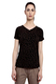

모델의 예측: {
  "gender": "Women",
  "masterCategory": "Clothing",
  "subCategory": "Top",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Black",
  "articleType": "T-shirt"
}
레이블: {"gender": "Women", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Fall", "usage": "Casual", "baseColour": "Black", "articleType": "Tops"}
--------------------------------------------------

--- 샘플 2 ---


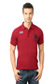

모델의 예측: {
  "gender": "Men",
  "masterCategory": "Clothing",
  "subCategory": "Shirts",
  "season": "Summer",
  "usage": "Casual",
  "baseColour": "Red",
  "articleType": "T-shirts"
}
레이블: {"gender": "Men", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Winter", "usage": "Casual", "baseColour": "Red", "articleType": "Tshirts"}
--------------------------------------------------

--- 샘플 3 ---


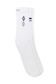

모델의 예측: {
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Socks",
  "season": "Spring",
  "usage": "Casual",
  "baseColour": "White",
  "articleType": "Socks"
}
레이블: {"gender": "Men", "masterCategory": "Accessories", "subCategory": "Socks", "season": "Summer", "usage": "Sports", "baseColour": "White", "articleType": "Socks"}
--------------------------------------------------

--- 샘플 4 ---


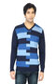

모델의 예측: {
  "gender": "Men",
  "masterCategory": "Clothing",
  "subCategory": "Sweaters",
  "season": "Fall/Winter",
  "usage": "Casual",
  "baseColour": "Navy Blue",
  "articleType": "Sweater"
}
레이블: {"gender": "Men", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Fall", "usage": "Casual", "baseColour": "Navy Blue", "articleType": "Sweaters"}
--------------------------------------------------

--- 샘플 5 ---


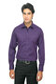

모델의 예측: {
  "gender": "Men",
  "masterCategory": "Clothing",
  "subCategory": "Shirts",
  "season": "Summer",
  "usage": "Casual",
  "baseColour": "Purple",
  "articleType": "Shirt"
}
레이블: {"gender": "Men", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Summer", "usage": "Casual", "baseColour": "Purple", "articleType": "Shirts"}
--------------------------------------------------


In [ ]:
from tqdm import tqdm
from IPython.display import display

# 전체 테스트 데이터에 대해 추론
predictions = []
labels = []

print(f"추론 시작... ({len(test_dataset)}건)")
for i, sample in enumerate(tqdm(test_dataset)):
    messages = sample["messages"]

    # 정답 레이블
    label = messages[2]["content"][0]["text"]
    labels.append(label)

    # 모델 추론
    pred = run_inference(model, processor, messages)
    predictions.append(pred)

# 결과 미리보기 (이미지 포함)
print("\n=== 추론 결과 (처음 5개) ===")
for i in range(min(5, len(predictions))):
    print(f"\n--- 샘플 {i+1} ---")

    # 이미지 표시
    image_inputs, _ = process_vision_info(test_dataset[i]["messages"])
    display(image_inputs[0])

    print(f"모델의 예측: {predictions[i]}")
    print(f"레이블: {labels[i]}")
    print("-" * 50)


## 6. 모델 평가 (F1 Score)

In [ ]:
from sklearn.metrics import f1_score
from collections import defaultdict

def calculate_f1_scores(predictions, labels):
    """각 key별로 F1 score를 계산하는 함수"""

    predictions_by_key = defaultdict(list)
    labels_by_key = defaultdict(list)

    for i in range(len(predictions)):
        # 모델 예측 파싱
        try:
            pred_json = json.loads(predictions[i])
        except:
            print(f"샘플 {i+1}: 예측 결과 JSON 파싱 실패 - {predictions[i][:100]}")
            continue

        # 레이블 파싱
        try:
            label_text = labels[i].strip()
            if label_text.endswith('<|im_end|>'):
                label_text = label_text[:-10]
            label_json = json.loads(label_text)
        except:
            print(f"샘플 {i+1}: 레이블 JSON 파싱 실패")
            continue

        for key in label_json.keys():
            if key in pred_json:
                predictions_by_key[key].append(pred_json[key])
                labels_by_key[key].append(label_json[key])
            else:
                print(f"샘플 {i+1}: 키 '{key}' 예측 결과에 없음")

    # F1 score 계산
    f1_scores = {}
    for key in labels_by_key.keys():
        if len(labels_by_key[key]) > 0:
            unique_labels = list(set(labels_by_key[key] + predictions_by_key[key]))
            if len(unique_labels) == 1:
                f1_scores[key] = 1.0
            else:
                f1_scores[key] = f1_score(
                    labels_by_key[key],
                    predictions_by_key[key],
                    labels=unique_labels,
                    average='macro',
                    zero_division=0
                )

    return f1_scores, predictions_by_key, labels_by_key

# F1 score 계산
f1_results, preds_by_key, labels_by_key_result = calculate_f1_scores(predictions, labels)

# 결과 출력
print("\n=== F1 Score 결과 ===")
print(f"{'Key':<15} {'F1 Score':<10} {'샘플 수':<8}")
print("-" * 35)

for key, score in f1_results.items():
    sample_count = len(labels_by_key_result[key])
    print(f"{key:<15} {score:.4f}     {sample_count}")

if f1_results:
    avg_f1 = sum(f1_results.values()) / len(f1_results)
    print("-" * 35)
    print(f"{'평균 F1':<15} {avg_f1:.4f}")

# 상세 결과
print("\n=== 상세 결과 ===")
for key in f1_results.keys():
    correct = sum(1 for p, l in zip(preds_by_key[key], labels_by_key_result[key]) if p == l)
    total = len(labels_by_key_result[key])
    accuracy = correct / total if total > 0 else 0
    print(f"{key}: 정확도 {accuracy:.4f} ({correct}/{total})")


=== F1 Score 결과 ===
Key             F1 Score   샘플 수    
-----------------------------------
gender          0.5000     10
masterCategory  0.1333     10
subCategory     0.1538     10
season          0.0889     10
usage           0.4737     10
baseColour      1.0000     10
articleType     0.1176     10
-----------------------------------
평균 F1           0.3525

=== 상세 결과 ===
gender: 정확도 0.9000 (9/10)
masterCategory: 정확도 0.2000 (2/10)
subCategory: 정확도 0.2000 (2/10)
season: 정확도 0.2000 (2/10)
usage: 정확도 0.9000 (9/10)
baseColour: 정확도 1.0000 (10/10)
articleType: 정확도 0.2000 (2/10)


실제 평가 결과, 전체 평균 F1 점수는 0.3525로 다소 낮게 측정됨. 하지만 이는 코드가 잘못된 것이 아니라 실습 환경의 물리적 한계

- 중요한 인사이트
1. **학습 데이터의 극단적 부족**
원본 데이터셋은 약 4,400개이지만, 코랩 실습 시간 관계상 **단 50개의 데이터만 추출하여 2 에포크(Epoch)만 훈련**했습니다. 모델이 7가지 복잡한 패션 속성의 패턴을 학습하기에는 매우 부족한 양입니다.
2. **무료 환경을 위한 극단적 모델 압축**
Colab 무료 환경(T4 GPU)에 올리기 위해 원래 7B(70억 파라미터) 크기의 모델을 2B(20억)로 줄이고, 4비트 양자화를 적용했으며, LoRA Rank마저 256에서 64로 대폭 축소했습니다. 뇌의 크기와 학습 여력을 강제로 줄였기 때문에 복잡한 추론 능력이 떨어집니다.
3. **속성별 추론 난이도의 차이 (가장 중요)**
    - **쉬운 속성**: `baseColour`(정확도 100%), `gender`(90%), `usage`(90%)처럼 직관적인 시각 정보만으로 맞출 수 있는 항목은 단 50개의 학습만으로도 완벽에 가까운 성능을 냅니다.
    - **어려운 속성**: 반면 `masterCategory`, `season`, `articleType` 등은 정확도가 20%대에 머물렀습니다. 이는 눈으로 보는 것을 넘어 "이 옷이 어느 카테고리의 분류 체계에 속하는가?"라는 **도메인 특화 지식**이 필요하기 때문입니다.

성능을 높이려면?      
실제 프로젝트를 진행할 때는 양자화 수준을 낮추거나 더 큰 GPU를 대여하고, 최소 수백~수천 개의 데이터를 충분한 에포크로 학습시킨다면(원본 4,400개 전체 사용) 실무에 활용 가능한 수준으로 성능이 상승할 것입니다.